In [1]:
import socket,warnings
try:
    socket.setdefaulttimeout(1)
    socket.socket(socket.AF_INET, socket.SOCK_STREAM).connect(('1.1.1.1', 53))
except socket.error as ex: raise Exception("STOP: No internet. Click '>|' in top right and set 'Internet' switch to on")

In [2]:
import os
iskaggle = os.environ.get('KAGGLE_KERNEL_RUN_TYPE', '')

if iskaggle:
    !pip install -qq fastai ddgs --use-deprecated=legacy-resolver 

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 1.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 52.4 MB/s eta 0:00:0000:0100:01


In [9]:
from ddgs import DDGS #DuckDuckGo has changed the api so we need to update 
from fastcore.all import *

def search_images(keywords, max_images=200): return L(DDGS().images(keywords, max_results=max_images)).itemgot('image')
import time, json

In [23]:
urls = search_images('bear photos', max_images=3)
urls[:3]

['https://images.pexels.com/photos/162340/bear-bavarian-bear-wild-brown-bear-162340.jpeg?cs=srgb&dl=pexels-pixabay-162340.jpg&fm=jpg', 'https://i.natgeofe.com/n/7bd4e32f-9caf-4f2f-96f9-aa456d99896f/MM10120_230829_14318_4x3.jpg', 'https://fthmb.tqn.com/5I5yYvEZcTZ361zX35sXRItXIDw=/3867x2578/filters:fill(auto,1)/getty-brown-bear-56afcf215f9b58b7d01d5195.jpg']

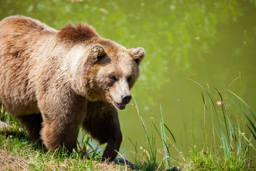

In [24]:
from fastdownload import download_url

download_url(urls[0], 'bear_0.jpg', show_progress=False)
download_url(urls[1], 'bear_2.jpg', show_progress=False)
download_url(urls[2], 'bear_3.jpg', show_progress=False)

from fastai.vision.all import *
im = Image.open('bear_0.jpg')
im.to_thumb(256,256)

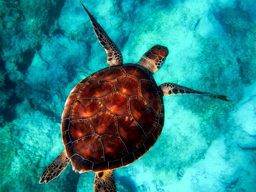

In [25]:
urls = search_images('turtle photos', max_images=3)[:3]

download_url(urls[0], 'turtle_0.jpg', show_progress=False)
download_url(urls[1], 'turtle_1.jpg', show_progress=False)
download_url(urls[2], 'turtle_2.jpg', show_progress=False)

Image.open('turtle_0.jpg').to_thumb(256,256)

In [33]:
searches = 'turtle','bear'
path = Path('turtle_or_bear')

for o in searches:
    dest = (path/o)
    dest.mkdir(exist_ok=True, parents=True)
    download_images(dest, urls=search_images(f'{o} photo'))
    time.sleep(5)
    resize_images(path/o, max_size=400, dest=path/o)

In [34]:
failed = verify_images(get_image_files(path))
failed.map(Path.unlink)
len(failed)

0

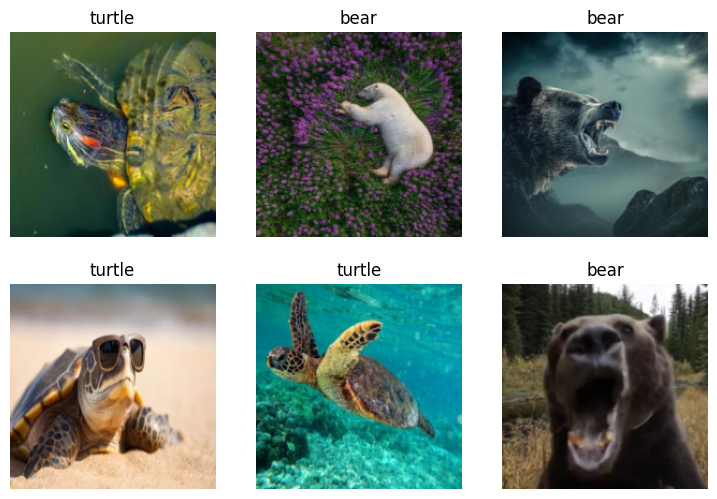

In [40]:
dls = DataBlock(
    blocks=(ImageBlock, CategoryBlock), 
    get_items=get_image_files, 
    splitter=RandomSplitter(valid_pct=0.2, seed=42),
    get_y=parent_label,
    item_tfms=[Resize(192, method='squish')]
).dataloaders(path, bs=32)

dls.show_batch(max_n=6)

**!NB** Note from me, Alex Kadiyski(me), when running in Kaggle, i needed to make sure that I switched to GPU T4 x 2 from GPU P100 (Tesla), since PyTorch was looking for sm_70 or newer and ENV preferences, should be Pin to original environment

In [41]:
learn = vision_learner(dls, resnet18, metrics=error_rate)
learn.fine_tune(3)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 148MB/s] 


epoch,train_loss,valid_loss,error_rate,time
0,1.065217,0.897097,0.388889,00:02


epoch,train_loss,valid_loss,error_rate,time
0,0.320989,0.357922,0.194444,00:01
1,0.187027,0.140768,0.055556,00:01
2,0.162315,0.149622,0.055556,00:01


In [44]:
pred, pred_idx, probs = learn.predict(PILImage.create('turtle_0.jpg'))
print(f"This is a: {pred}.")
print(f"Probability it's a turtle: {probs[dls.vocab.o2i['turtle']]:.4f}")
print(f"Probability it's a bear: {probs[dls.vocab.o2i['bear']]:.4f}")

This is a: turtle.
Probability it's a turtle: 0.9999
Probability it's a bear: 0.0001
